# Multiple sequence alignment with R

## MSA manual

### Imports

In [5]:
library(msa)
library(seqinr)
library(MSA2dist)
library(ape)
library(DT)



### Fasta to df function


In [6]:
read_fasta_to_dataframe <- function(filename) {
  fasta_sequences <- seqinr::read.fasta(filename, seqtype = "DNA")
  ids <- names(fasta_sequences)
  sequences <- sapply(fasta_sequences, function(seq) paste(seq, collapse = " "))
  df <- data.frame(id = ids, sequence = sequences)
  return(df)
}

### Set Working Directory and read input table

In [7]:
setwd("C:\\Users\\arayi\\Desktop\\Биоинформатика\\Лекция 4")

insulins_df <- read_fasta_to_dataframe("C:\\Users\\arayi\\Desktop\\Биоинформатика\\Data\\insulins.fasta")

print(insulins_df, max = 1000)  # Prints all rows

                                       id
sp|P01308|INS_HUMAN   sp|P01308|INS_HUMAN
sp|P01315|INS_PIG       sp|P01315|INS_PIG
sp|P01317|INS_BOVIN   sp|P01317|INS_BOVIN
sp|P01322|INS1_RAT     sp|P01322|INS1_RAT
sp|P01325|INS1_MOUSE sp|P01325|INS1_MOUSE
sp|P67970|INS_CHICK   sp|P67970|INS_CHICK
                                                                                                                                                                                                                                        sequence
sp|P01308|INS_HUMAN  m a l w m r l l p l l a l l a l w g p d p a a a f v n q h l c g s h l v e a l y l v c g e r g f f y t p k t r r e a e d l q v g q v e l g g g p g a g s l q p l a l e g s l q k r g i v e q c c t s i c s l y q l e n y c n
sp|P01315|INS_PIG        m a l w t r l l p l l a l l a l w a p a p a q a f v n q h l c g s h l v e a l y l v c g e r g f f y t p k a r r e a e n p q a g a v e l g g g l g g l q a l a l e g p p q k r g i v e q c c t s i c s l

## MSA

### create sequence object, translating the DNA-sequences

In [8]:
# Remove all spaces from sequences
insulins_df$sequence <- gsub(" ", "", insulins_df$sequence)

# Also remove any other potential problematic characters
insulins_df$sequence <- gsub("[^A-Za-z]", "", insulins_df$sequence)

# Now create the AAStringSet
seq <- AAStringSet(insulins_df$sequence)
names(seq) <- insulins_df$id

# Perform MSA
msa_alignments <- msa(seq,
    method = "ClustalOmega"   # Possible values: ClustalOmega, ClustalW, Muscle
)


using Gonnet


### Show alignment

In [31]:
msa_alignments

ClustalOmega 1.2.0 

Call:
   msa(seq, method = "ClustalOmega")

MsaAAMultipleAlignment with 6 rows and 110 columns
    aln                                                                                                            names
[1] MALWIRSLPLLALLVFSGPGTSYAAANQHLCGSHLVEALYLVCGERGFFYSPKARRDVEQPLVSSPLRG-E--AGVLPFQQEEYEKVKRGIVEQCCHNTCSLYQLENYCN sp|P67970|INS_CHICK
[2] MALWMRFLPLLALLVLWEPKPAQAFVKQHLCGPHLVEALYLVCGERGFFYTPKSRREVEDPQVPQLELGGGPEAGDLQTLALEVARQKRGIVDQCCTSICSLYQLENYCN sp|P01322|INS1_RAT
[3] MALLVHFLPLLALLALWEPKPTQAFVKQHLCGPHLVEALYLVCGERGFFYTPKSRREVEDPQVEQLELGGSP--GDLQTLALEVARQKRGIVDQCCTSICSLYQLENYCN sp|P01325|INS1_MOUSE
[4] MALWTRLRPLLALLALWPPPPARAFVNQHLCGSHLVEALYLVCGERGFFYTPKARREVEGPQVGALELAGGPGAGGL-----EGPPQKRGIVEQCCASVCSLYQLENYCN sp|P01317|INS_BOVIN
[5] MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN sp|P01308|INS_HUMAN
[6] MALWTRLLPLLALLALWAPAPAQAFVNQHLCGSHLVEALYLVCGERGFFYTPKARREAENPQAGAVELGGGL--GGLQALALEG

In [32]:
print(msa_alignments, showConsensus=TRUE, halfNrow=3, show="complete")


MsaAAMultipleAlignment with 6 rows and 110 columns
    aln                                                                                                            names
[1] MALWIRSLPLLALLVFSGPGTSYAAANQHLCGSHLVEALYLVCGERGFFYSPKARRDVEQPLVSSPLRG-E--AGVLPFQQEEYEKVKRGIVEQCCHNTCSLYQLENYCN sp|P67970|INS_CHICK
[2] MALWMRFLPLLALLVLWEPKPAQAFVKQHLCGPHLVEALYLVCGERGFFYTPKSRREVEDPQVPQLELGGGPEAGDLQTLALEVARQKRGIVDQCCTSICSLYQLENYCN sp|P01322|INS1_RAT
[3] MALLVHFLPLLALLALWEPKPTQAFVKQHLCGPHLVEALYLVCGERGFFYTPKSRREVEDPQVEQLELGGSP--GDLQTLALEVARQKRGIVDQCCTSICSLYQLENYCN sp|P01325|INS1_MOUSE
[4] MALWTRLRPLLALLALWPPPPARAFVNQHLCGSHLVEALYLVCGERGFFYTPKARREVEGPQVGALELAGGPGAGGL-----EGPPQKRGIVEQCCASVCSLYQLENYCN sp|P01317|INS_BOVIN
[5] MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN sp|P01308|INS_HUMAN
[6] MALWTRLLPLLALLALWAPAPAQAFVNQHLCGSHLVEALYLVCGERGFFYTPKARREAENPQAGAVELGGGL--GGLQALALEGPPQKRGIVEQCCTSICSLYQLENYCN sp|P01315|INS_PIG
Con MALW?RLLPLLALLA

### save pretty alignment

In [37]:
# First, check your current working directory
getwd()

# Create the PDF with a specific filename
msaPrettyPrint(msa_alignments,
                output="pdf",
                showNames="left",
                showLogo="top",
                askForOverwrite=FALSE,
                verbose=FALSE,
                paperWidth=13, 
                paperHeight=5,
                file="msa_alignment.pdf"  # Specify output filename
            )

# The PDF will be saved in your working directory
print(paste("PDF saved to:", file.path(getwd(), "msa_alignment.pdf")))

[1] "C:/Users/arayi/Desktop/Биоинформатика/Лекция 4"

[1] "PDF saved to: C:/Users/arayi/Desktop/Биоинформатика/Лекция 4/msa_alignment.pdf"


## Phylogeny

### Create distances matrix

In [9]:
distances <- aastring2dist(seq,score=granthamMatrix())
head(distances$distSTRING)


Computing: [========================================] 100% (done)                         


,sp|P01308|INS_HUMAN,sp|P01315|INS_PIG,sp|P01317|INS_BOVIN,sp|P01322|INS1_RAT,sp|P01325|INS1_MOUSE,sp|P67970|INS_CHICK
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sp|P01308|INS_HUMAN,0.00000,41.27778,32.74074,12.90741,44.53704,50.06481
sp|P01315|INS_PIG,41.27778,0.00000,34.25000,44.47222,15.56481,53.77778
sp|P01317|INS_BOVIN,32.74074,34.25000,0.00000,35.75000,39.84259,52.31481
sp|P01322|INS1_RAT,12.90741,44.47222,35.75000,0.00000,38.48148,49.35185
sp|P01325|INS1_MOUSE,44.53704,15.56481,39.84259,38.48148,0.00000,56.50926
sp|P67970|INS_CHICK,50.06481,53.77778,52.31481,49.35185,56.50926,0.00000


### Plot phylogeny tree based on distances


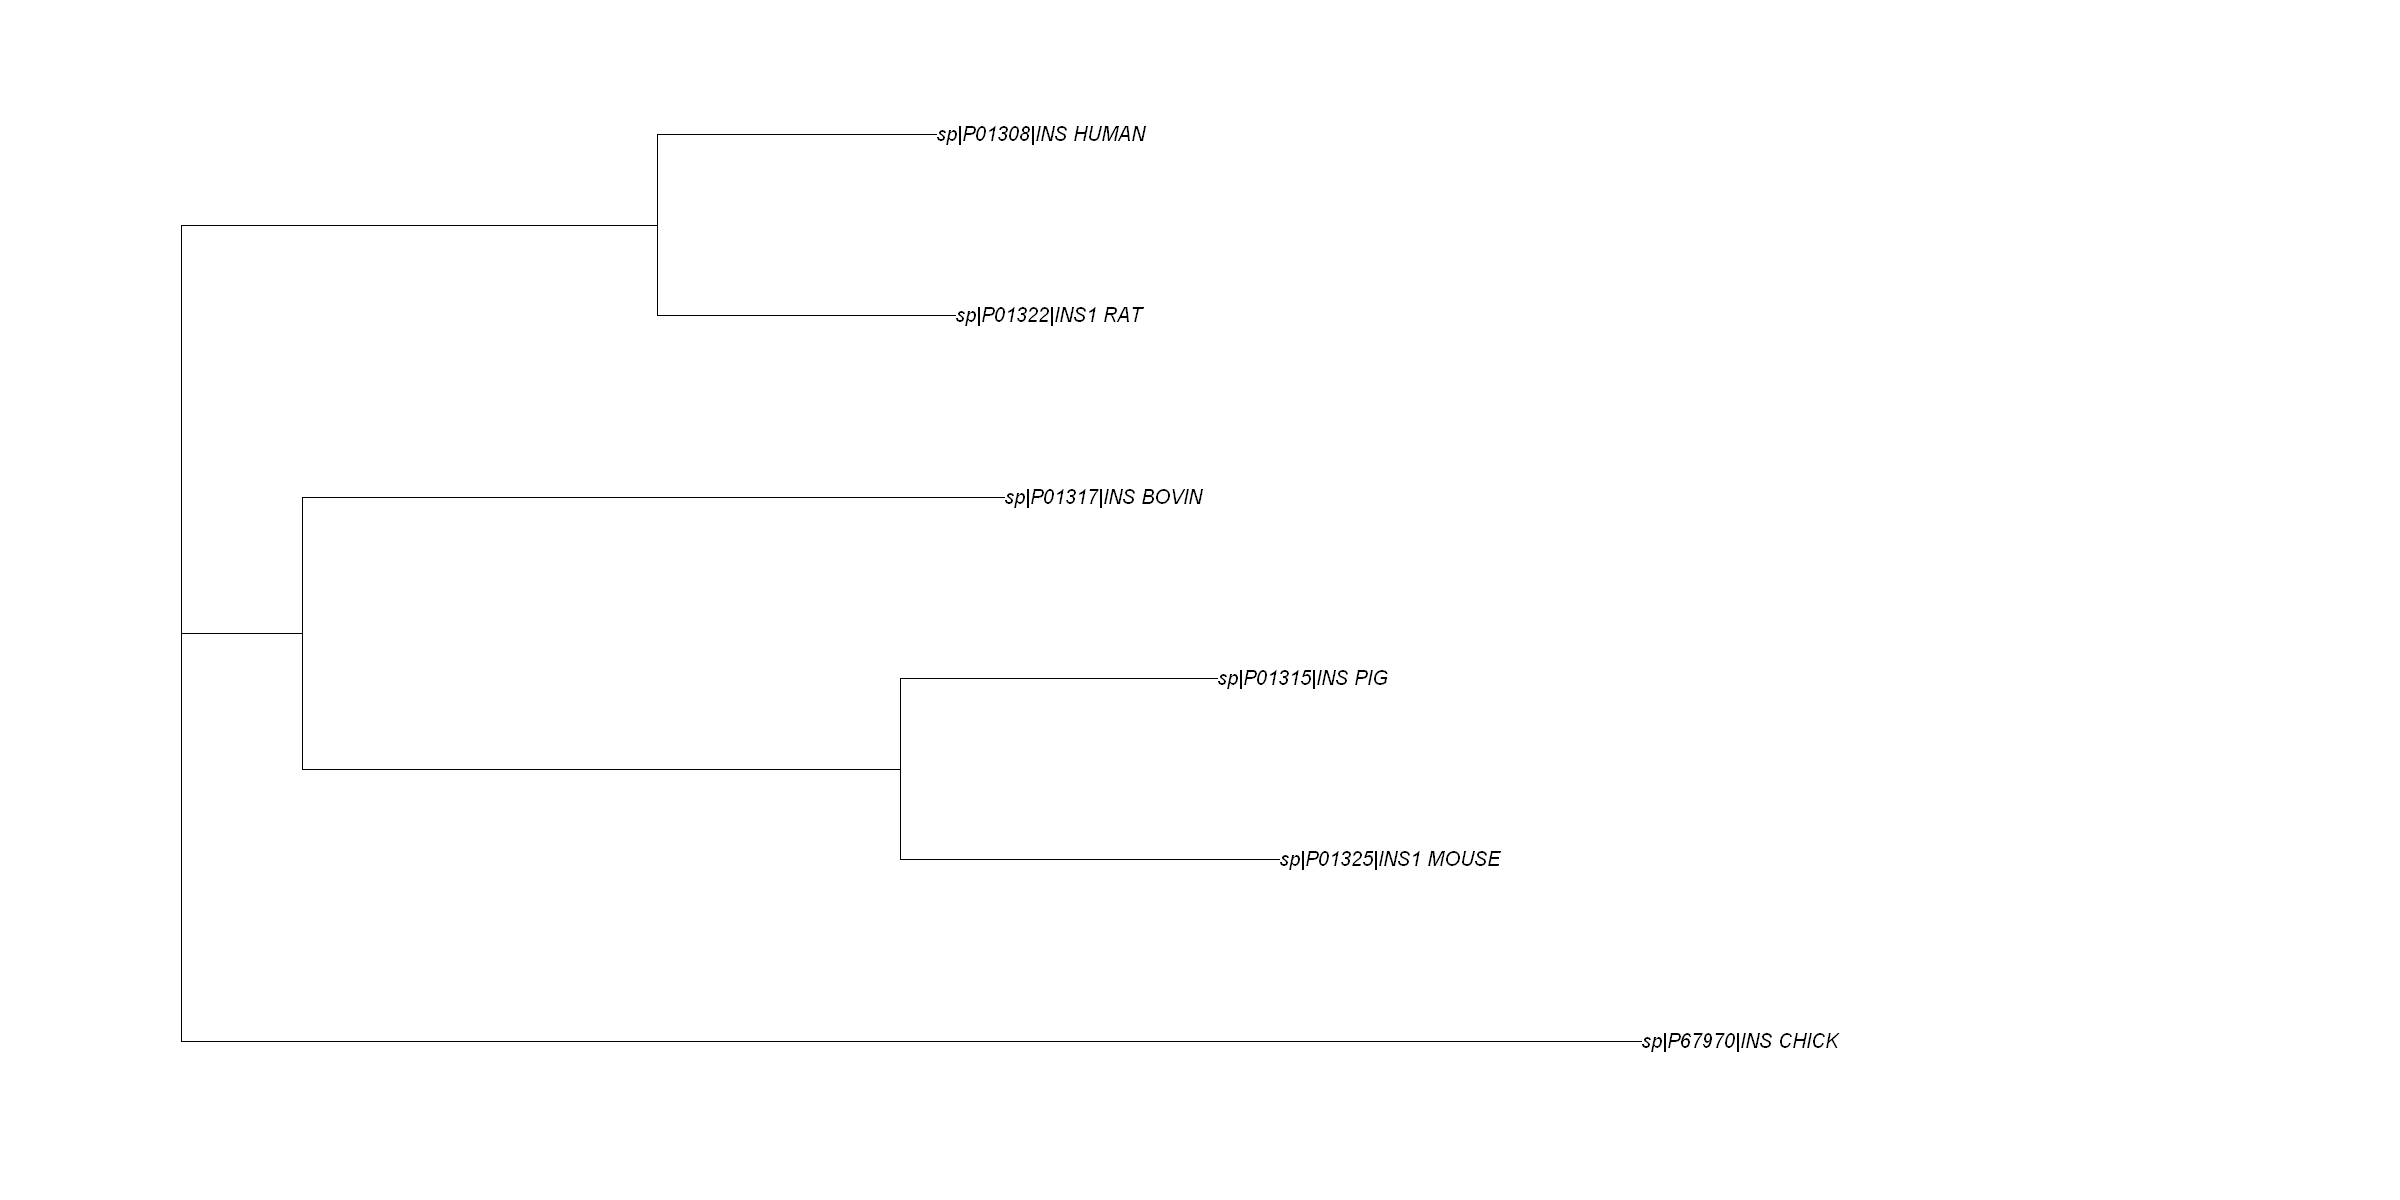

In [10]:
options(repr.plot.width = 20, repr.plot.height = 10)

distances_bionj <- ape::bionj(as.dist(distances$distSTRING))
plot(distances_bionj)